## 3. LaTeX alternative forms (same equation)

$$x_{n+1} = r x_n (1 - x_n)$$

or if you want full expansion:

$$x_{n+1} = r x_n - r x_n^2$$

## 4. Mathematical notation without subscript $n$ (as a function)

$$f(x) = r x (1 - x)$$

with $x_{n+1} = f(x_n)$.

---

## Stability Criterion for Fixed Points

$$|f'(z^*)| < 1 \quad \text{attracts}, \qquad |f'(z^*)| > 1 \quad \text{repels}$$

You're referring to the **stability criterion for fixed points** in dynamical systems.

Given a map $x_{n+1} = f(x_n)$ with a fixed point $x^*$ (where $x^* = f(x^*)$), the derivative $f'(x^*)$ determines the local stability:

- **If $|f'(x^*)| < 1$**: The fixed point is **attracting** (stable). Nearby points converge to $x^*$.
- **If $|f'(x^*)| > 1$**: The fixed point is **repelling** (unstable). Nearby points move away from $x^*$.
- **If $|f'(x^*)| = 1$**: The stability is **indeterminate** from linearization (neutral/weakly stable, may require higher-order terms).

---

## Applied to the logistic map $f(x) = r x (1 - x)$

First, find $f'(x)$:

$$f'(x) = r(1 - 2x)$$

### Fixed points

Set $x = r x (1 - x)$:

1. **$x^* = 0$** (trivial fixed point)
2. **$x^* = 1 - \frac{1}{r}$** (nontrivial fixed point, exists for $r > 1$)

### Stability

**At $x^* = 0$:**

$$f'(0) = r$$

- Attracting if $|r| < 1$ (but for logistic map, typically $r > 0$, so $0 < r < 1$)
- Repelling if $r > 1$

**At $x^* = 1 - \frac{1}{r}$:**

$$f'\left(1 - \frac{1}{r}\right) = r\left(1 - 2\left[1 - \frac{1}{r}\right]\right) = r\left(1 - 2 + \frac{2}{r}\right) = r\left(-1 + \frac{2}{r}\right) = -r + 2$$

$$f'(x^*) = 2 - r$$

- Attracting if $|2 - r| < 1 \rightarrow 1 < r < 3$
- Repelling if $|2 - r| > 1 \rightarrow r < 1$ (irrelevant here since $r > 1$ needed for existence) or $r > 3$

---

## Summary for logistic map

| Range of $r$ | Behavior |
|--------------|----------|
| $0 < r < 1$ | Only fixed point $x^* = 0$, attracting (population dies out) |
| $1 < r < 3$ | $x^* = 0$ repelling, $x^* = 1 - 1/r$ attracting |
| $r = 3$ | $f'(x^*) = -1$ (bifurcation point, period-doubling) |
| $r > 3$ | Nontrivial fixed point repelling, stable period-2 orbit appears |

This is exactly where the logistic map transitions into periodic and then chaotic behavior.

In [1]:
def logistic_map(r, x):
    return r*x*(1-x)

In [2]:

x = 0.5 #initial condition
r = 3.8 #paramater

for n in range(100):
    x = logistic_map(r, x)
    print(x)


0.95
0.18050000000000016
0.5620950500000005
0.9353479781088904
0.22979412423470422
0.6725573818672562
0.8368510098598481
0.5188193091943221
0.9486541676855043
0.1850958637100242
0.5731744628003645
0.9296528923767365
0.2485138898747569
0.7096679983734816
0.7829494557406192
0.6457705008851319
0.8692536520724515
0.43187661363839625
0.932364976076385
0.23963000435737464
0.6923883684024251
0.8093495196731204
0.5863509237764368
0.9216653682592327
0.2743536054010614
0.7565180774971003
0.6999542084853282
0.7980695951342224
0.6123871625347789
0.9020026776500485
0.3358966192163266
0.8476663055784008
0.4906869318687708
0.9496704136955357
0.18162677237816585
0.5648262541478919
0.9340307157379811
0.23414588362470812
0.6814220374639884
0.8249269684251775
0.5488053677220899
0.940948537109744
0.21114467295895145
0.6329378801520338
0.8828445760785973
0.3930341161553565
0.90652153883467
0.32201290616126915
0.8296182588220027
0.5371368531143748
0.9447592457348931
0.19831901066665003
0.6041566065644344
0.

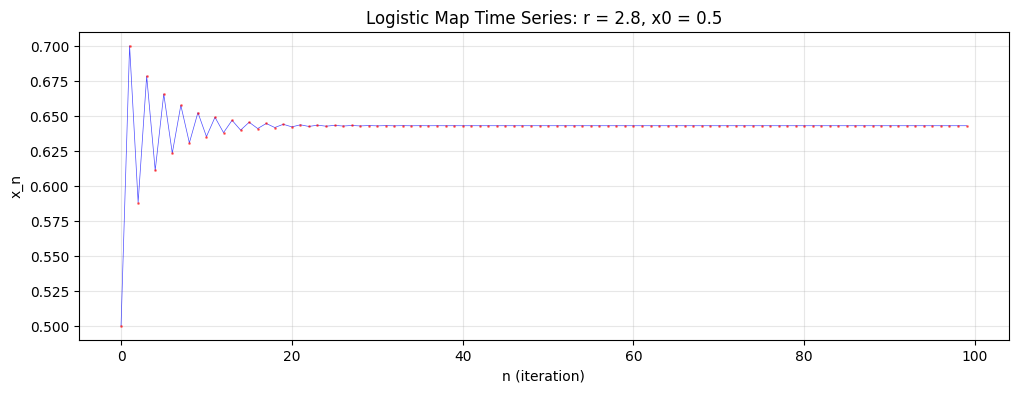

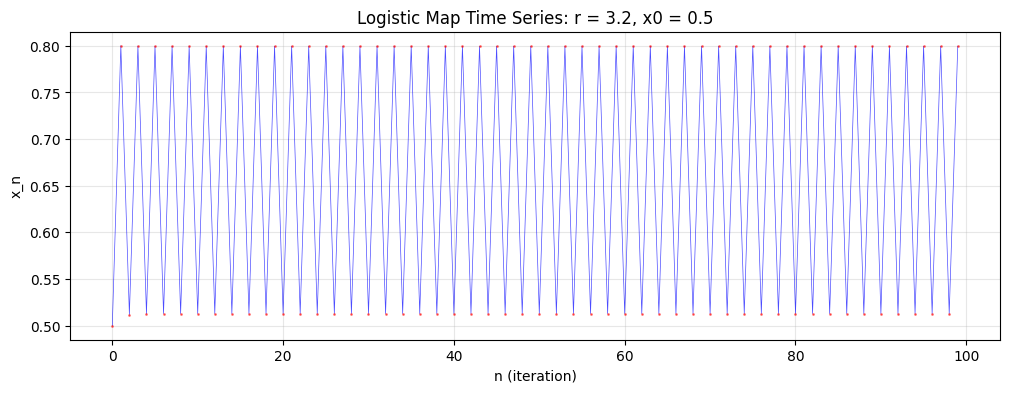

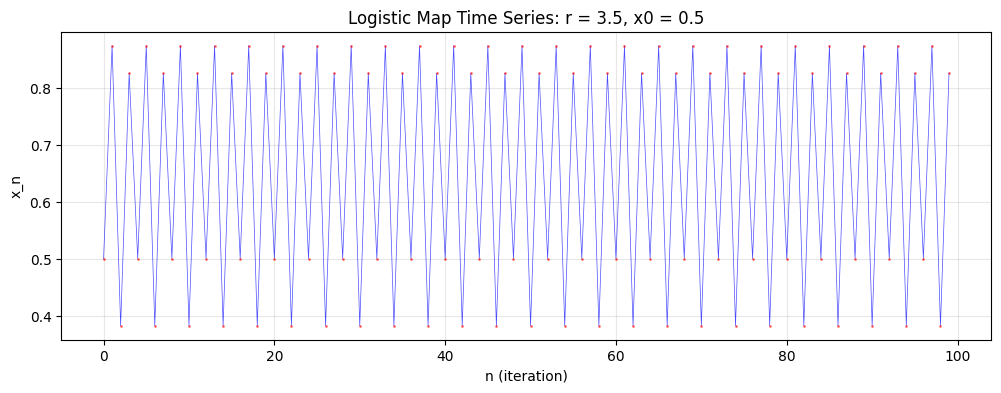

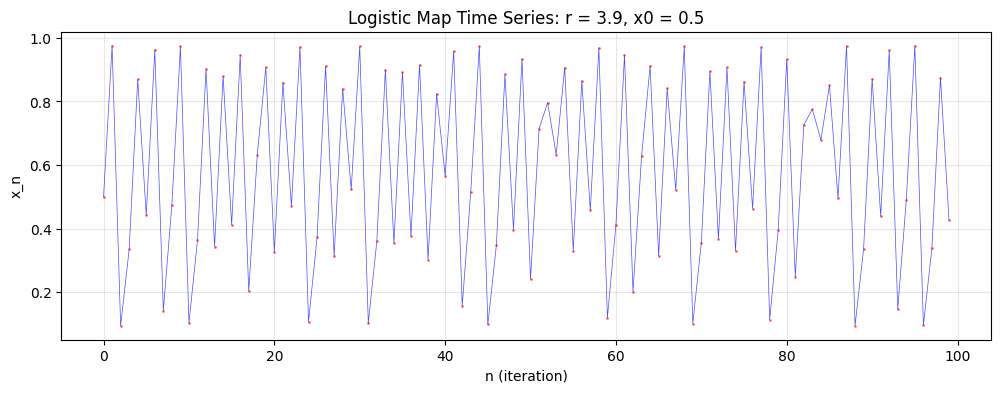

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


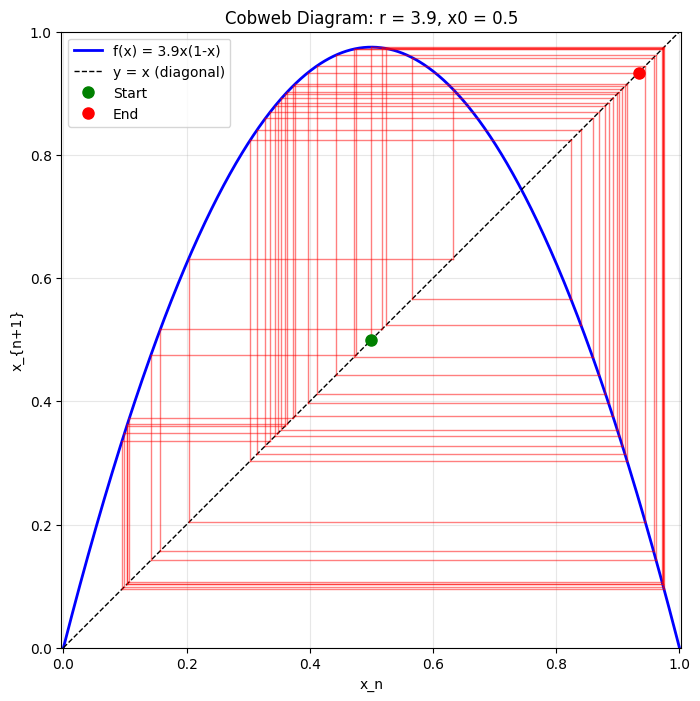

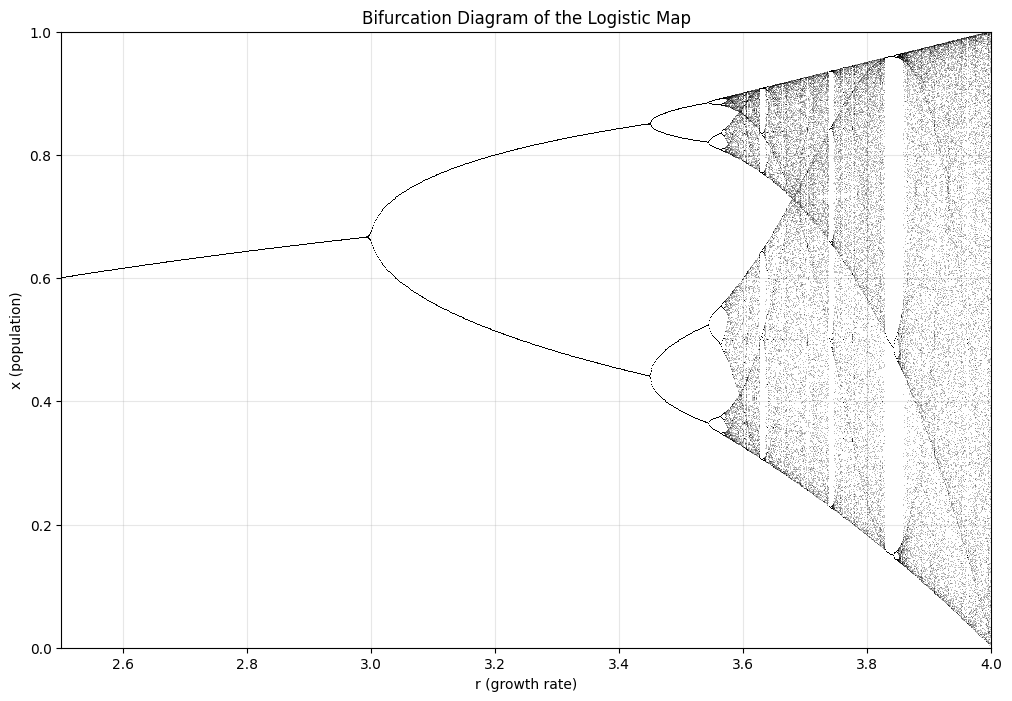

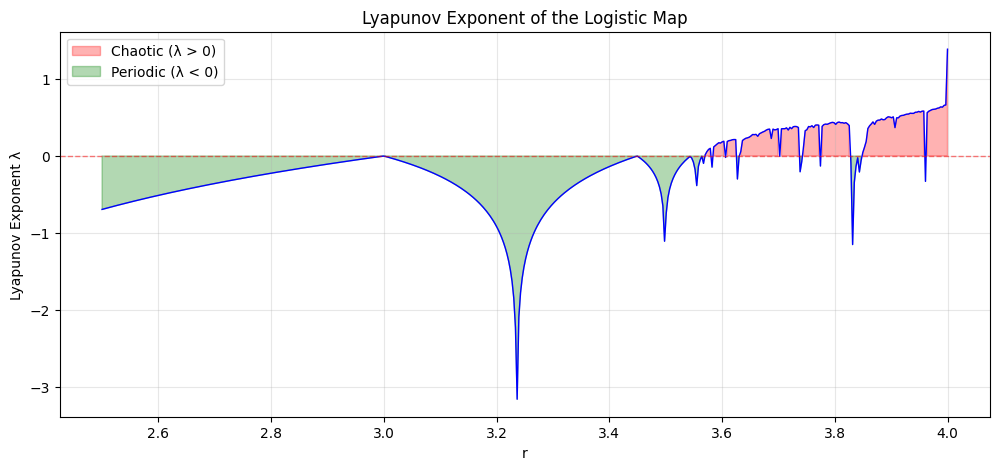

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_map(r, x):
    """Logistic map function: x_{n+1} = r * x * (1 - x)"""
    return r * x * (1 - x)

# ============================================
# 1. TIME SERIES PLOT (trajectory over time)
# ============================================
def plot_time_series(r, x0, n_iterations=100):
    """Plot the trajectory of the logistic map over time"""
    x = np.zeros(n_iterations)
    x[0] = x0
    
    for i in range(n_iterations - 1):
        x[i + 1] = logistic_map(r, x[i])
    
    plt.figure(figsize=(12, 4))
    plt.plot(range(n_iterations), x, 'b-', linewidth=0.5, alpha=0.7)
    plt.plot(range(n_iterations), x, 'r.', markersize=2, alpha=0.5)
    plt.xlabel('n (iteration)')
    plt.ylabel('x_n')
    plt.title(f'Logistic Map Time Series: r = {r}, x0 = {x0}')
    plt.grid(True, alpha=0.3)
    plt.show()

# ============================================
# 2. COBWEB PLOT (graphical iteration)
# ============================================
def plot_cobweb(r, x0, n_iterations=50):
    """Draw the cobweb diagram for the logistic map"""
    # Generate function curve
    x_vals = np.linspace(0, 1, 1000)
    y_vals = logistic_map(r, x_vals)
    
    # Generate trajectory
    x_traj = np.zeros(n_iterations)
    x_traj[0] = x0
    for i in range(n_iterations - 1):
        x_traj[i + 1] = logistic_map(r, x_traj[i])
    
    # Create cobweb plot
    plt.figure(figsize=(8, 8))
    plt.plot(x_vals, y_vals, 'b-', linewidth=2, label=f'f(x) = {r}x(1-x)')
    plt.plot(x_vals, x_vals, 'k--', linewidth=1, label='y = x (diagonal)')
    
    # Draw cobweb steps
    for i in range(n_iterations - 1):
        # Vertical line from (x_i, x_i) to (x_i, x_{i+1})
        plt.plot([x_traj[i], x_traj[i]], [x_traj[i], x_traj[i+1]], 'r-', linewidth=1, alpha=0.5)
        # Horizontal line from (x_i, x_{i+1}) to (x_{i+1}, x_{i+1})
        plt.plot([x_traj[i], x_traj[i+1]], [x_traj[i+1], x_traj[i+1]], 'r-', linewidth=1, alpha=0.5)
    
    plt.plot(x_traj[0], x_traj[0], 'go', markersize=8, label='Start')
    plt.plot(x_traj[-1], x_traj[-1], 'ro', markersize=8, label='End')
    
    plt.xlabel('x_n')
    plt.ylabel('x_{n+1}')
    plt.title(f'Cobweb Diagram: r = {r}, x0 = {x0}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

# ============================================
# 3. BIFURCATION DIAGRAM (classic chaos plot)
# ============================================
def plot_bifurcation(r_min=2.5, r_max=4.0, n_transient=500, n_plot=200, n_r=1000):
    """Plot the bifurcation diagram of the logistic map"""
    r_vals = np.linspace(r_min, r_max, n_r)
    x = 0.5 * np.ones_like(r_vals)  # Initial condition
    
    plt.figure(figsize=(12, 8))
    
    for i in range(n_transient + n_plot):
        x = logistic_map(r_vals, x)
        if i >= n_transient:
            plt.plot(r_vals, x, ',k', alpha=0.25, markersize=0.5)
    
    plt.xlabel('r (growth rate)')
    plt.ylabel('x (population)')
    plt.title('Bifurcation Diagram of the Logistic Map')
    plt.xlim(r_min, r_max)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

# ============================================
# 4. LYAPUNOV EXPONENT (chaos indicator)
# ============================================
def lyapunov_exponent(r, n_iterations=10000, n_transient=1000):
    """Calculate the Lyapunov exponent for a given r"""
    x = 0.5
    lyap = 0.0
    
    # Transient iterations
    for _ in range(n_transient):
        x = logistic_map(r, x)
    
    # Calculate Lyapunov exponent
    for _ in range(n_iterations):
        x = logistic_map(r, x)
        lyap += np.log(abs(r * (1 - 2 * x)))
    
    return lyap / n_iterations

def plot_lyapunov(r_min=2.5, r_max=4.0, n_points=500):
    """Plot the Lyapunov exponent as a function of r"""
    r_vals = np.linspace(r_min, r_max, n_points)
    lyap_vals = [lyapunov_exponent(r) for r in r_vals]
    
    plt.figure(figsize=(12, 5))
    plt.plot(r_vals, lyap_vals, 'b-', linewidth=1)
    plt.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5)
    plt.fill_between(r_vals, 0, lyap_vals, where=(np.array(lyap_vals) > 0), 
                     color='red', alpha=0.3, label='Chaotic (λ > 0)')
    plt.fill_between(r_vals, 0, lyap_vals, where=(np.array(lyap_vals) < 0), 
                     color='green', alpha=0.3, label='Periodic (λ < 0)')
    plt.xlabel('r')
    plt.ylabel('Lyapunov Exponent λ')
    plt.title('Lyapunov Exponent of the Logistic Map')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ============================================
# EXAMPLE USAGE
# ============================================

# Different regimes of the logistic map
r_values = {
    'Fixed point': 2.8,
    'Period-2': 3.2,
    'Period-4': 3.5,
    'Chaos': 3.9
}

# Plot time series for different r values
for regime, r in r_values.items():
    plot_time_series(r, x0=0.5, n_iterations=100)

# Cobweb plot for chaotic regime
plot_cobweb(r=3.9, x0=0.5, n_iterations=50)

# Bifurcation diagram (classic)
plot_bifurcation()

# Lyapunov exponent plot
plot_lyapunov()